# K-Nearest Neighbors (KNN) Classifier

## What is KNN?

K-Nearest Neighbors (KNN) is a **supervised classification algorithm** that predicts the class of a new data point based on the **majority class of its K nearest training data points**.

Examples:

* Spam / Not Spam
* Loan Approved / Rejected
* Disease Positive / Negative
* Customer Will Buy / Will Not Buy

KNN is called a **lazy learning algorithm** because it **does not build a mathematical model during training**. It simply stores the training data.

---

# How KNN Works

Suppose:

| Age | Income | Buy |
| --- | ------ | --- |
| 22  | 25k    | No  |
| 25  | 30k    | No  |
| 35  | 60k    | Yes |
| 40  | 65k    | Yes |
| 42  | 70k    | Yes |

New customer:

```text
Age = 38
Income = 62k
```

Choose:

```text
K = 3
```

Nearest neighbors:

```text
35,60k → Yes
40,65k → Yes
42,70k → Yes
```

Majority vote:

```text
Yes
```

Prediction:

```text
Buy = Yes
```

---

# What Does K Mean?

K is the **number of nearest neighbors** considered.

Examples:

```text
K = 1
```

Use only the closest point.

```text
K = 3
```

Use the 3 closest points.

```text
K = 5
```

Use the 5 closest points.

Choosing K is a **hyperparameter tuning problem**.

---

# Distance in KNN

The most common distance metric is **Euclidean Distance**.

Distance between two points:

```text
d = √[(x₂ − x₁)² + (y₂ − y₁)²]
```

Example:

```text
A = (2,3)
B = (5,7)

Distance
= √[(5−2)² + (7−3)²]
= √(9 + 16)
= √25
= 5
```

KNN computes the distance from the new point to **every training point**.

---

# Why Scaling is Important

Suppose:

| Feature | Range            |
| ------- | ---------------- |
| Age     | 18–60            |
| Salary  | 20,000–1,000,000 |

Without scaling:

```text
Age difference    = 5
Salary difference = 50,000
```

Salary dominates the distance calculation.

Therefore KNN usually requires:

```python
StandardScaler()
```

After scaling:

```text
Age      Salary

-0.8     -1.1
-0.3     -0.4
```

Both features contribute fairly.

---

# Why OneHotEncoder is Needed

Suppose:

| Age | Gender | Buy |
| --- | ------ | --- |
| 25  | Male   | Yes |
| 30  | Female | No  |

KNN cannot use text values directly.

Use:

```python
OneHotEncoder()
```

Result:

| Male | Female |
| ---- | ------ |
| 1    | 0      |
| 0    | 1      |

---

# Why ColumnTransformer?

Real datasets contain both **numerical and categorical features**.

Example:

| Column | Type        |
| ------ | ----------- |
| Age    | Numerical   |
| Salary | Numerical   |
| Gender | Categorical |
| City   | Categorical |

We want:

```text
Numerical
    ↓
StandardScaler

Categorical
    ↓
OneHotEncoder
```

This is handled by:

```python
ColumnTransformer()
```

---

# Pipeline + KNN

```python
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

numeric_features = ["Age", "Salary"]
categorical_features = ["Gender", "City"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(), categorical_features)
])

model = Pipeline([
    ("preprocessor", preprocessor),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])
```

Flow:

```text
Raw Data
    ↓
ColumnTransformer
    ├── StandardScaler
    └── OneHotEncoder
    ↓
KNN Classifier
```

---

# Training and Prediction

```python
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
```

The Pipeline automatically performs:

* Encoding
* Scaling
* Classification

---

# Important Hyperparameters

| Parameter   | Meaning                                      |
| ----------- | -------------------------------------------- |
| n_neighbors | Number of neighbors (K)                      |
| weights     | Uniform or distance-based voting             |
| metric      | Distance metric (Euclidean, Manhattan, etc.) |

Example:

```python
KNeighborsClassifier(
    n_neighbors=5,
    weights="uniform"
)
```

---

# Choosing the Best K

Small K:

```text
K = 1
```

* Very flexible
* Can overfit
* Sensitive to noise

Large K:

```text
K = 50
```

* Very smooth
* Can underfit
* Ignores local patterns

Typical approach:

```python
params = {
    "knn__n_neighbors": [3,5,7,9,11]
}
```

Use:

```python
GridSearchCV()
```

to find the best K.

---

# Evaluation Metrics

For classification:

* Accuracy
* Precision
* Recall
* F1 Score
* Confusion Matrix
* ROC-AUC

---

# Advantages of KNN

* Very easy to understand
* No training phase
* Can model non-linear decision boundaries
* Works well for small and medium datasets

---

# Disadvantages of KNN

* Prediction becomes slow for large datasets
* Requires feature scaling
* Sensitive to irrelevant features
* Sensitive to the choice of K

---

# Interview Answer

**What is KNN?**

K-Nearest Neighbors (KNN) is a supervised classification algorithm that predicts the class of a new data point based on the majority class of its K nearest training data points using a distance metric such as Euclidean distance.

---

# Quick Recall Diagram

```text
Training Data
      ● ● ●
   ●  ●  ●  ○
      ○ ○ ○
         ?

Choose K
    ↓
Compute Distances
    ↓
Select K Nearest Points
    ↓
Majority Vote
    ↓
Predicted Class
```

---

# KNN Workflow

```text
Raw Data
    ↓
Train/Test Split
    ↓
ColumnTransformer
    ├── StandardScaler
    └── OneHotEncoder
    ↓
KNN Classifier
    ↓
Cross Validation
    ↓
GridSearchCV (Best K)
    ↓
Final Prediction
```

---

# Golden Rule

**KNN predicts by comparing a new point with the nearest training points, so feature scaling is usually essential and categorical features should be encoded before distance calculations.**


In [1]:
from ucimlrepo import fetch_ucirepo 

# fetch dataset 
spambase = fetch_ucirepo(id=94) 
  
# data (as pandas dataframes) 
X = spambase.data.features 
y = spambase.data.targets 

In [2]:
X.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,word_freq_conference,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.0,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.0,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.0,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.0,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.0,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191


In [3]:
X.shape

(4601, 57)

In [4]:
y.sample(10
    )

,Class
106,1
4392,0
847,1
3115,0
3877,0
684,1
4253,0
3227,0
4521,0
3567,0


In [5]:
X.isnull().sum()

word_freq_make                0
word_freq_address             0
word_freq_all                 0
word_freq_3d                  0
word_freq_our                 0
word_freq_over                0
word_freq_remove              0
word_freq_internet            0
word_freq_order               0
word_freq_mail                0
word_freq_receive             0
word_freq_will                0
word_freq_people              0
word_freq_report              0
word_freq_addresses           0
word_freq_free                0
word_freq_business            0
word_freq_email               0
word_freq_you                 0
word_freq_credit              0
word_freq_your                0
word_freq_font                0
word_freq_000                 0
word_freq_money               0
word_freq_hp                  0
word_freq_hpl                 0
word_freq_george              0
word_freq_650                 0
word_freq_lab                 0
word_freq_labs                0
word_freq_telnet              0
word_fre

In [6]:
X.describe()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,word_freq_conference,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total
count,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,...,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000
mean,0.104553,0.213015,0.280656,0.065425,0.312223,0.095901,0.114208,0.105295,0.090067,0.239413,...,0.031869,0.038575,0.139030,0.016976,0.269071,0.075811,0.044238,5.191515,52.172789,283.289285
std,0.305358,1.290575,0.504143,1.395151,0.672513,0.273824,0.391441,0.401071,0.278616,0.644755,...,0.285735,0.243471,0.270355,0.109394,0.815672,0.245882,0.429342,31.729449,194.891310,606.347851
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.588000,6.000000,35.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.065000,0.000000,0.000000,0.000000,0.000000,2.276000,15.000000,95.000000
75%,0.000000,0.000000,0.420000,0.000000,0.380000,0.000000,0.000000,0.000000,0.000000,0.160000,...,0.000000,0.000000,0.188000,0.000000,0.315000,0.052000,0.000000,3.706000,43.000000,266.000000
max,4.540000,14.280000,5.100000,42.810000,10.000000,5.880000,7.270000,11.110000,5.260000,18.180000,...,10.000000,4.385000,9.752000,4.081000,32.478000,6.003000,19.829000,1102.500000,9989.000000,15841.000000


In [7]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 57 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report            4601 

In [8]:
X.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
4596    False
4597    False
4598    False
4599    False
4600    False
Length: 4601, dtype: bool

In [9]:
y[y.duplicated()].value_counts()

Class
0        2787
1        1812
Name: count, dtype: int64

In [10]:
import pandas as pd 
mails = pd.concat([X,y],axis=1)
mails

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,Class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.000,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.010,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4596,0.31,0.00,0.62,0.0,0.00,0.31,0.00,0.00,0.00,0.00,...,0.000,0.232,0.0,0.000,0.000,0.000,1.142,3,88,0
4597,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.353,0.000,0.000,1.555,4,14,0
4598,0.30,0.00,0.30,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.102,0.718,0.0,0.000,0.000,0.000,1.404,6,118,0
4599,0.96,0.00,0.00,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.057,0.0,0.000,0.000,0.000,1.147,5,78,0


In [11]:
mails.duplicated().sum()

391

In [12]:
mails = mails.drop_duplicates()
mails

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,Class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.000,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.010,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4596,0.31,0.00,0.62,0.0,0.00,0.31,0.00,0.00,0.00,0.00,...,0.000,0.232,0.0,0.000,0.000,0.000,1.142,3,88,0
4597,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.353,0.000,0.000,1.555,4,14,0
4598,0.30,0.00,0.30,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.102,0.718,0.0,0.000,0.000,0.000,1.404,6,118,0
4599,0.96,0.00,0.00,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.057,0.0,0.000,0.000,0.000,1.147,5,78,0


In [13]:
mails.isnull().sum()

word_freq_make                0
word_freq_address             0
word_freq_all                 0
word_freq_3d                  0
word_freq_our                 0
word_freq_over                0
word_freq_remove              0
word_freq_internet            0
word_freq_order               0
word_freq_mail                0
word_freq_receive             0
word_freq_will                0
word_freq_people              0
word_freq_report              0
word_freq_addresses           0
word_freq_free                0
word_freq_business            0
word_freq_email               0
word_freq_you                 0
word_freq_credit              0
word_freq_your                0
word_freq_font                0
word_freq_000                 0
word_freq_money               0
word_freq_hp                  0
word_freq_hpl                 0
word_freq_george              0
word_freq_650                 0
word_freq_lab                 0
word_freq_labs                0
word_freq_telnet              0
word_fre

In [14]:
mails.columns

Index(['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d',
       'word_freq_our', 'word_freq_over', 'word_freq_remove',
       'word_freq_internet', 'word_freq_order', 'word_freq_mail',
       'word_freq_receive', 'word_freq_will', 'word_freq_people',
       'word_freq_report', 'word_freq_addresses', 'word_freq_free',
       'word_freq_business', 'word_freq_email', 'word_freq_you',
       'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000',
       'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george',
       'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet',
       'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85',
       'word_freq_technology', 'word_freq_1999', 'word_freq_parts',
       'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting',
       'word_freq_original', 'word_freq_project', 'word_freq_re',
       'word_freq_edu', 'word_freq_table', 'word_freq_conference',


In [15]:
print(mails.columns.tolist())

['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology', 'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project', 'word_freq_re', 'word_freq_edu', 'word_freq_table', 'word_freq_conference', 'char_freq_;', 'char_freq_(', 'char_freq_[', 'char_freq_!', 'char_freq_$', 'char_freq_#', 'capita

In [16]:
mails = X.copy()
mails["Class"] = y

In [17]:
sns.barplot(data=mails, x="Class", y="word_freq_free")
plt.show()

NameError: name 'sns' is not defined

In [ ]:
y.head()

In [ ]:
mails = X.copy()
mails["Class"] = y.iloc[:, 0]

In [ ]:
mails.columns.tolist()

In [ ]:
print(mails.columns.tolist())

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

features = [col for col in mails.columns if col != "Class"]

for feature in features:
    plt.figure(figsize=(5,3))
    sns.barplot(data=mails, x="Class", y=feature)
    plt.title(feature)
    plt.tight_layout()
    plt.show()

In [ ]:
feature_diff = (
    mails.groupby("Class").mean().diff().iloc[-1].abs().sort_values(ascending=False)
)

top_features = feature_diff.head(10)
print(top_features)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot only the selected top features
for feature in top_features.index:
    plt.figure(figsize=(6,3))
    sns.barplot(data=mails, x="Class", y=feature)
    plt.title(feature)
    plt.tight_layout()
    plt.show()

In [ ]:
selected_features = [
    "capital_run_length_total",
    "capital_run_length_longest",
    "capital_run_length_average",
    "word_freq_george",
    "word_freq_you",
    "word_freq_your",
    "word_freq_hp",
    "word_freq_free",
    "word_freq_hpl",
    "char_freq_!"
]

x = mails[selected_features]
y = mails["Class"]

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
knn_model = Pipeline([
    ("scalar",StandardScaler()),
    ("knn",KNeighborsClassifier())
])
knn_model.fit(X_train,y_train)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = knn_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

In [ ]:
from sklearn.model_selection import GridSearchCV

params = {
    "knn__n_neighbors": [3,5,7,9,11,15,21]
}

grid = GridSearchCV( knn_model, params, cv=5, scoring="accuracy" )

grid.fit(X_train, y_train)

print("Best K:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

In [ ]:
from sklearn.metrics import accuracy_score

best_knn = grid.best_estimator_

# Predictions
train_pred = best_knn.predict(X_train)
test_pred = best_knn.predict(X_test)

# Accuracy
train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy :", test_acc)

In [ ]:
best_knn = grid.best_estimator_

y_pred = best_knn.predict(X_test)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Why Did GridSearchCV Change from K=7 to K=3?

The training data changed.

First split:

```python
train_test_split(X, y, test_size=0.2, random_state=42)
```

Second split:

```python
train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
```

Adding `stratify=y` creates a **different training set** while preserving class proportions.

KNN is sensitive to the exact training points, so the best value of `K` can change.

GridSearchCV selects the `K` with the **highest average cross-validation accuracy**.

A change from **K=7 to K=3** is normal when the training split changes.

The important comparison is the **CV accuracy**, not just the value of `K`.


# Classification Evaluation Metrics Cheat Sheet

## Step 1: Start with the Confusion Matrix

```text id=
```


## Step 1: Start with the Confusion Matrix

A confusion matrix is the **foundation of all classification metrics**.

```text
                    Predicted
                Negative   Positive

Actual Negative     TN         FP
Actual Positive     FN         TP
```

### Meaning of each term

* **TN (True Negative):** Actual negative predicted as negative.
* **FP (False Positive):** Actual negative predicted as positive.
* **FN (False Negative):** Actual positive predicted as negative.
* **TP (True Positive):** Actual positive predicted as positive.

Example (Spam Classification):

```text
                    Predicted
                Not Spam   Spam

Actual Not Spam     493      65
Actual Spam          59     304
```

Interpretation:

* **493** → Correctly identified non-spam emails (**TN**)
* **65** → Normal emails wrongly marked as spam (**FP**)
* **59** → Spam emails missed by the model (**FN**)
* **304** → Correctly detected spam emails (**TP**)

All major classification metrics (Accuracy, Precision, Recall, F1-score, and Specificity) are calculated from these four values.


## Step 2: Accuracy

### Formula

```text id=
```


## Step 2: Accuracy

### Formula

```text
Accuracy = (TP + TN) / (TP + TN + FP + FN)
```

### What does Accuracy mean?

Accuracy tells us **how many predictions the model got correct out of all predictions**.

### Example

Confusion Matrix:

```text
                    Predicted
                Not Spam   Spam

Actual Not Spam     493      65
Actual Spam          59     304
```

Here:

* **TP = 304**
* **TN = 493**
* **FP = 65**
* **FN = 59**

Calculation:

```text
Accuracy = (304 + 493) / (304 + 493 + 65 + 59)

         = 797 / 921

         = 0.865
```

**Accuracy = 86.5%**

### Interpretation

Out of **921 emails**, the model correctly classified **797 emails**.

### When should I use Accuracy?

Use Accuracy when the classes are **balanced** (roughly similar numbers of Class 0 and Class 1).

Examples:

* Cat vs Dog
* Apple vs Orange
* Digit classification

### When should I avoid Accuracy?

Avoid Accuracy when the dataset is **imbalanced**.

Example:

```text
990 normal emails
10 spam emails
```

If the model predicts **all emails as normal**:

```text
Accuracy = 990 / 1000 = 99%
```

The model looks excellent, but it detected **zero spam emails**.

### Memory Trick

```text
Accuracy = Overall Correctness
```

Ask yourself:

> “Out of everything, how many predictions were correct?”


## Step 3: Precision

### Formula

```text id=
```


## Step 3: Precision

### Formula

```text
Precision = TP / (TP + FP)
```

### What does Precision mean?

Precision answers:

> **When the model predicts Positive, how often is it correct?**

It measures the **quality of positive predictions**.

### Example

Confusion Matrix:

```text
                    Predicted
                Not Spam   Spam

Actual Not Spam     493      65
Actual Spam          59     304
```

For the **Spam class (Positive = Spam)**:

* **TP = 304**
* **FP = 65**

Calculation:

```text
Precision = 304 / (304 + 65)

          = 304 / 369

          = 0.824
```

**Precision = 82.4%**

### Interpretation

The model predicted **369 emails as Spam**.

Out of those, **304 were actually Spam**.

So when the model says **“Spam”**, it is correct **82.4% of the time**.

### When should I use Precision?

Use Precision when **False Positives are expensive**.

Examples:

* Spam detection (important emails should not go to spam)
* Loan approval
* Criminal identification
* Medical diagnosis where unnecessary treatment is harmful

### Real-World Example

Suppose a spam filter predicts:

```text
Predicted Spam = 100 emails
Actually Spam  = 90 emails
```

Then:

```text
Precision = 90 / 100 = 90%
```

This means **10 normal emails were incorrectly marked as spam**.

### High vs Low Precision

**High Precision**

```text
Predicted Spam → Mostly true spam
```

Few false alarms.

**Low Precision**

```text
Predicted Spam → Many normal emails included
```

Lots of false alarms.

### Memory Trick

```text
Precision = “When I say YES, am I right?”
```

Ask yourself:

> **“Among all emails predicted as Spam, how many were actually Spam?”**


## Step 4: Recall (Sensitivity)

### Formula

```text id=
```


## Step 4: Recall (Sensitivity)

### Formula

```text
Recall = TP / (TP + FN)
```

### What does Recall mean?

Recall answers:

> **Of all actual positive cases, how many did the model correctly identify?**

It measures the model’s ability to **find positive cases**.

### Example

Confusion Matrix:

```text
                    Predicted
                Not Spam   Spam

Actual Not Spam     493      65
Actual Spam          59     304
```

For the **Spam class (Positive = Spam)**:

* **TP = 304**
* **FN = 59**

Calculation:

```text
Recall = 304 / (304 + 59)

       = 304 / 363

       = 0.838
```

**Recall = 83.8%**

### Interpretation

There were **363 actual spam emails**.

The model correctly detected **304 of them**.

So the model found **83.8% of all spam emails**.

### When should I use Recall?

Use Recall when **False Negatives are expensive**.

Examples:

* Cancer detection
* Fraud detection
* Disease screening
* Intrusion detection
* Spam filtering (when missing spam is dangerous)

### Real-World Example

Suppose:

```text
Actual Fraud Cases = 100
Detected Fraud = 95
```

Then:

```text
Recall = 95 / 100 = 95%
```

This means the model successfully found **95% of all fraud cases**.

### High vs Low Recall

**High Recall**

```text
Most actual positive cases are detected.
```

Few missed positives.

**Low Recall**

```text
Many actual positive cases are missed.
```

Many false negatives.

### Precision vs Recall

```text
Precision → Correctness of positive predictions.

Recall    → Completeness of positive detection.
```

### Memory Trick

```text
Recall = “Did I find all YES cases?”
```

Ask yourself:

> **“Among all actual Spam emails, how many did the model detect?”**


## Step 5: F1 Score

### Formula

```text id=
```



## Step 5: F1 Score

### Formula

```text
F1 Score = 2 × (Precision × Recall) / (Precision + Recall)
```

### What does F1 Score mean?

F1 Score is the **harmonic mean of Precision and Recall**.

It gives a **single score that balances both metrics**.

### Example

From our previous calculations:

```text
Precision = 0.824
Recall    = 0.838
```

Calculation:

```text
F1 = 2 × (0.824 × 0.838) / (0.824 + 0.838)

   = 2 × 0.690 / 1.662

   = 0.830
```

**F1 Score = 83.0%**

### Interpretation

The model has a good balance between:

* Correctly predicting Spam (Precision)
* Detecting all Spam emails (Recall)

### When should I use F1 Score?

Use F1 Score when:

* The dataset is **imbalanced**
* Both **Precision and Recall are important**
* You need a **single metric** to compare models

Examples:

* Spam detection
* Fraud detection
* Medical diagnosis
* Information retrieval

### Why not just use Accuracy?

Example:

```text
990 normal emails
10 spam emails
```

Model predicts everything as normal.

```text
Accuracy = 99%
Precision = 0
Recall = 0
F1 = 0
```

Accuracy looks excellent, but the model completely fails to detect spam.

F1 exposes this problem.

### High vs Low F1 Score

**High F1**

```text
Precision high
Recall high
```

Balanced and reliable model.

**Low F1**

```text
Precision low
or
Recall low
```

The model is weak in detecting positive cases or produces many false alarms.

### Memory Trick

```text
F1 Score = Balance of Precision and Recall
```

Ask yourself:

> **“Does my model both predict positive cases correctly and detect most of the actual positive cases?”**


## Step 6: Specificity (True Negative Rate)

### Formula

```text id=
```


## Step 6: Specificity (True Negative Rate)

### Formula

```text
Specificity = TN / (TN + FP)
```

### What does Specificity mean?

Specificity answers:

> **Of all actual negative cases, how many did the model correctly identify?**

It measures the model’s ability to **identify negative cases correctly**.

### Example

Confusion Matrix:

```text
                    Predicted
                Not Spam   Spam

Actual Not Spam     493      65
Actual Spam          59     304
```

For the **Not Spam class (Negative = Not Spam)**:

* **TN = 493**
* **FP = 65**

Calculation:

```text
Specificity = 493 / (493 + 65)

            = 493 / 558

            = 0.883
```

**Specificity = 88.3%**

### Interpretation

There were **558 actual non-spam emails**.

The model correctly identified **493 of them**.

So the model correctly recognized **88.3% of all non-spam emails**.

### When should I use Specificity?

Use Specificity when **correctly identifying negative cases is important**.

Examples:

* Healthy patient identification
* Legitimate transaction detection
* Non-spam email recognition
* Quality control (identifying non-defective products)

### High vs Low Specificity

**High Specificity**

```text
Most actual negative cases are identified correctly.
```

Few false positives.

**Low Specificity**

```text
Many negative cases are wrongly predicted as positive.
```

Many false positives.

### Recall vs Specificity

```text
Recall      → Detects Positive cases correctly.

Specificity → Detects Negative cases correctly.
```

### Memory Trick

```text
Specificity = “Did I correctly reject the NO cases?”
```

Ask yourself:

> **“Among all actual Not Spam emails, how many did the model correctly identify as Not Spam?”**


## Step 7: ROC Curve (Receiver Operating Characteristic Curve)

### What is the ROC Curve?

The **ROC Curve** shows the performance of a classification model at **different probability thresholds**.

It compares:

```text
True Positive Rate (Recall)
            vs
False Positive Rate (FPR)
```

### Formula

```text
True Positive Rate (TPR) = TP / (TP + FN)

False Positive Rate (FPR) = FP / (FP + TN)
```

### What does the ROC Curve show?

As the **classification threshold** changes, the values of **TPR** and **FPR** change.

Example:

```text
Threshold = 0.3 → More emails predicted as Spam
Threshold = 0.7 → Fewer emails predicted as Spam
```

The ROC curve helps us understand the trade-off between:

* Detecting more positive cases (higher Recall)
* Producing more false positives

### Visual Intuition

```text
TPR (Recall)
1.0 |                             *
    |                         *
0.8 |                     *
    |                 *
0.6 |             *
    |         *
0.4 |     *
    |  *
0.2 |*
    +------------------------------------
      0.0   0.2   0.4   0.6   0.8   1.0
               FPR
```

A curve closer to the **top-left corner** indicates a better classifier.

### When should I use ROC Curve?

Use ROC Curve when:

* Comparing multiple classification models
* Evaluating different probability thresholds
* Working with binary classification problems

Examples:

* Spam detection
* Fraud detection
* Medical diagnosis
* Credit risk prediction

### Interpretation

**Better Model**

```text
High TPR
Low FPR
```

**Worse Model**

```text
Low TPR
High FPR
```

### Memory Trick

```text
ROC Curve = “How does the model perform as the decision threshold changes?”
```

Ask yourself:

> **“Can I increase Recall without increasing too many False Positives?”**


# Decision Tree Classification

## Objective

Build a **Decision Tree Classifier** to classify emails as **spam** or **non-spam** using the **Spambase dataset**.

## Dataset

The **Spambase dataset** contains numerical features extracted from email messages, including:

* Word frequency features
* Character frequency features
* Capital letter statistics

**Target variable:** `Class`

* `1` → Spam
* `0` → Not Spam

## What is a Decision Tree?

A **Decision Tree** is a supervised machine learning algorithm used for **classification and regression** tasks. It works by repeatedly splitting the data into smaller subsets based on feature values until a prediction can be made.

The tree consists of:

* **Root Node** – the first decision point
* **Decision Nodes** – intermediate splits
* **Leaf Nodes** – final predicted class

## Splitting Criteria

The algorithm selects the best feature for splitting using an impurity measure such as:

* **Gini Impurity**
* **Entropy (Information Gain)**

The feature that produces the purest child nodes is chosen for the split.

## Workflow

1. Load the Spambase dataset
2. Separate features (`X`) and target (`y`)
3. Split the data into training and testing sets
4. Train a `DecisionTreeClassifier`
5. Predict on the test set
6. Evaluate using:

   * Accuracy
   * Confusion Matrix
   * Precision
   * Recall
   * F1-score

## Advantages

* Easy to understand and visualize
* Handles numerical and categorical features
* Does not require feature scaling
* Provides feature importance

## Disadvantages

* Can easily **overfit** the training data
* Sensitive to small changes in the dataset
* Deep trees may have poor generalization on unseen data

## Goal

Train and evaluate a Decision Tree model and compare its performance with other classification algorithms such as **KNN** and **Logistic Regression** on the same Spambase dataset.


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Train-test split (same variables we have been using)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)



In [48]:
# Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)

# Train the model
dt_model.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=5, random_state=42)

In [49]:
# Predictions
y_pred = dt_model.predict(X_test)

# Evaluation
print("Train Accuracy:", accuracy_score(y_train, dt_model.predict(X_train)))
print("Test Accuracy :", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Train Accuracy: 0.9233695652173913
Test Accuracy : 0.8990228013029316

Confusion Matrix:
[[527  31]
 [ 62 301]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.94      0.92       558
           1       0.91      0.83      0.87       363

    accuracy                           0.90       921
   macro avg       0.90      0.89      0.89       921
weighted avg       0.90      0.90      0.90       921



In [50]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [51]:
dt = DecisionTreeClassifier(random_state=42)

In [52]:
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

In [53]:
grid = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)

In [54]:
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 10, 15, 20, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy')

In [55]:
print("Best Parameters:", grid.best_params_)

Best Parameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2}


In [56]:
print("Best CV Accuracy:", grid.best_score_)

Best CV Accuracy: 0.9334239130434783


In [57]:
best_dt = grid.best_estimator_

In [58]:
DecisionTreeClassifier(
    criterion="entropy",
    max_depth=10,
    min_samples_leaf=2,
    min_samples_split=5,
    random_state=42
)

DecisionTreeClassifier(criterion='entropy', max_depth=10, min_samples_leaf=2,
                       min_samples_split=5, random_state=42)

In [59]:
y_pred = best_dt.predict(X_test)

In [60]:
train_acc = accuracy_score(y_train, best_dt.predict(X_train))
test_acc = accuracy_score(y_test, y_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy :", test_acc)

Train Accuracy: 0.9891304347826086
Test Accuracy : 0.9207383279044516


In [61]:
 cm = confusion_matrix(y_test, y_pred)
print(cm)

[[522  36]
 [ 37 326]]


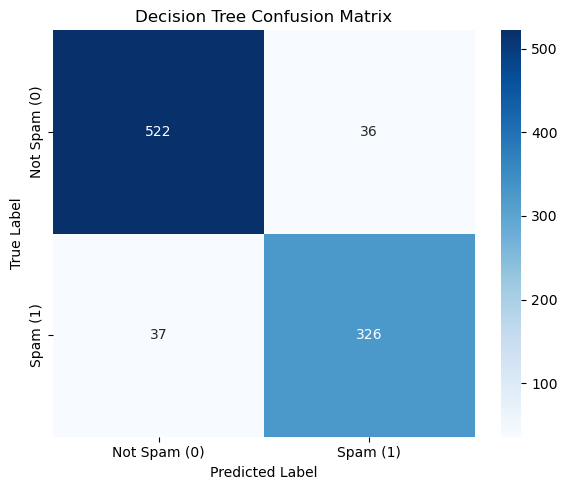

In [62]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Spam (0)", "Spam (1)"],
    yticklabels=["Not Spam (0)", "Spam (1)"]
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

### Confusion Matrix Interpretation

* **Top-left (TN):** Correctly classified **Not Spam** emails.
* **Top-right (FP):** Not Spam emails incorrectly classified as **Spam**.
* **Bottom-left (FN):** Spam emails incorrectly classified as **Not Spam**.
* **Bottom-right (TP):** Correctly classified **Spam** emails.

A good spam classifier aims to maximize **True Positives** and **True Negatives** while minimizing **False Positives** and **False Negatives**.


In [63]:
from sklearn.tree import plot_tree

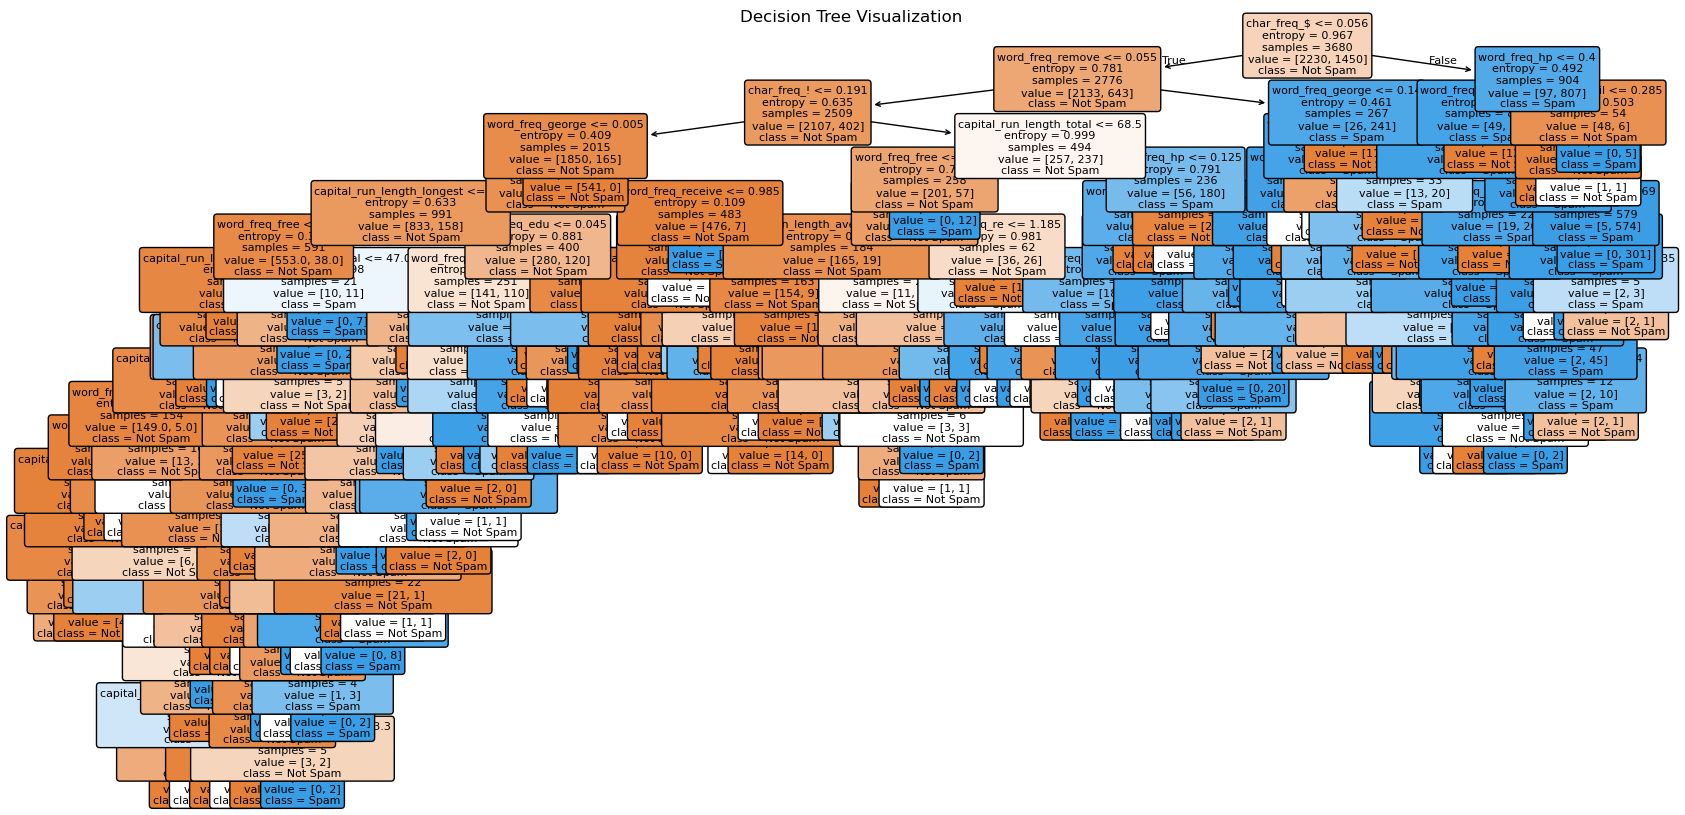

In [64]:
plt.figure(figsize=(20, 10))

plot_tree(
    best_dt,
    
    feature_names=X.columns,
    class_names=["Not Spam", "Spam"],
    filled=True,
    rounded=True,
    fontsize=8,
)

plt.title("Decision Tree Visualization")
plt.show()

In [65]:
import pandas as pd

feature_importance = pd.Series(
    best_dt.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)

char_freq_$                   0.273033
word_freq_remove              0.130162
char_freq_!                   0.106430
word_freq_hp                  0.079045
capital_run_length_total      0.051486
word_freq_george              0.045165
word_freq_edu                 0.043582
capital_run_length_longest    0.040290
capital_run_length_average    0.037761
word_freq_you                 0.024303
dtype: float64

## iranian churn

# Decision Tree Classification on the UCI Iranian Churn Dataset

## Objective

The objective of this project is to build a **Decision Tree Classifier** to predict whether a telecom customer is likely to **churn (leave the service)** or **remain with the company**.

## Dataset

The **UCI Iranian Churn Dataset** contains customer-related information such as service usage patterns, account details, and other behavioral attributes.

**Target Variable:** `Churn`

* `1` → Customer churned
* `0` → Customer did not churn

## Machine Learning Workflow

This notebook follows an **industry-standard machine learning workflow**, including:

1. Exploratory Data Analysis (EDA)
2. Missing value analysis
3. Train-test split
4. Decision Tree model training
5. Hyperparameter tuning using **GridSearchCV**
6. Model evaluation using **Accuracy, Precision, Recall, F1-score, and Confusion Matrix**
7. Feature importance analysis
8. Decision Tree visualization
9. Business interpretation of the model results

The goal is not only to achieve good predictive performance but also to build an **interpretable model** that can help telecom companies understand the factors influencing customer churn.


In [66]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
iranian_churn = fetch_ucirepo(id=563) 
  
# data (as pandas dataframes) 
X = iranian_churn.data.features 
y = iranian_churn.data.targets 

In [67]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
)

In [68]:
X.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
3145     True
3146     True
3147     True
3148     True
3149     True
Length: 3150, dtype: bool

In [70]:
y.duplicated()

0       False
1        True
2        True
3        True
4        True
        ...  
3145     True
3146     True
3147     True
3148     True
3149     True
Length: 3150, dtype: bool

In [71]:
churn = X.copy()
churn["Churn"] = y

print(churn.shape)
churn.head()

(3150, 14)


,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


In [72]:
churn.shape

(3150, 14)

In [73]:
churn.columns

Index(['Call  Failure', 'Complains', 'Subscription  Length', 'Charge  Amount',
       'Seconds of Use', 'Frequency of use', 'Frequency of SMS',
       'Distinct Called Numbers', 'Age Group', 'Tariff Plan', 'Status', 'Age',
       'Customer Value', 'Churn'],
      dtype='object')

In [74]:
# Basic information
print("Shape:", churn.shape)
print("\nColumns:\n", churn.columns)
print("\nData Types:\n", churn.dtypes)

# Missing values
print("\nMissing Values:\n", churn.isnull().sum())

# Duplicate rows
print("\nDuplicate Rows:", churn.duplicated().sum())

Shape: (3150, 14)

Columns:
 Index(['Call  Failure', 'Complains', 'Subscription  Length', 'Charge  Amount',
       'Seconds of Use', 'Frequency of use', 'Frequency of SMS',
       'Distinct Called Numbers', 'Age Group', 'Tariff Plan', 'Status', 'Age',
       'Customer Value', 'Churn'],
      dtype='object')

Data Types:
 Call  Failure                int64
Complains                    int64
Subscription  Length         int64
Charge  Amount               int64
Seconds of Use               int64
Frequency of use             int64
Frequency of SMS             int64
Distinct Called Numbers      int64
Age Group                    int64
Tariff Plan                  int64
Status                       int64
Age                          int64
Customer Value             float64
Churn                        int64
dtype: object

Missing Values:
 Call  Failure              0
Complains                  0
Subscription  Length       0
Charge  Amount             0
Seconds of Use             0
Frequency 

## Initial EDA Findings

* The dataset contains **3150 rows and 14 columns**.
* There are **13 input features** and **1 target variable (`Churn`)**.
* All columns are numeric (`int64` or `float64`).
* **No missing values** are present in the dataset.
* The dataset contains **300 duplicate rows** (approximately **9.5%** of the data), which should be considered during preprocessing to avoid potential bias in model training.


In [75]:
# Remove duplicate rows
churn = churn.drop_duplicates()

print("New Shape:", churn.shape)
print("Remaining Duplicates:", churn.duplicated().sum())

New Shape: (2850, 14)
Remaining Duplicates: 0


In [76]:
# Class distribution
churn["Churn"].value_counts()

Churn
0    2404
1     446
Name: count, dtype: int64

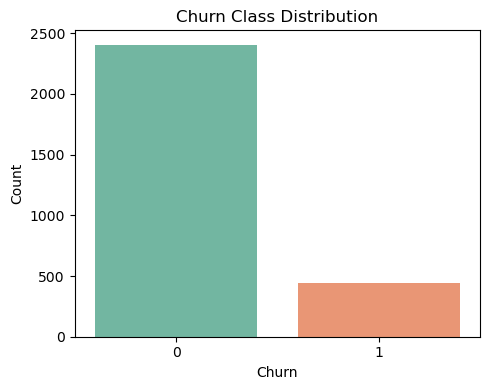

In [77]:
plt.figure(figsize=(5, 4))
sns.countplot(data=churn, x="Churn", hue="Churn", palette="Set2", legend=False)

plt.title("Churn Class Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Target Distribution

The target variable (`Churn`) is **imbalanced**.

|             Churn |    Count | Percentage |
| ----------------: | -------: | ---------: |
| **0 (Not Churn)** | **2404** | **84.35%** |
|     **1 (Churn)** |  **446** | **15.65%** |

Since the classes are not evenly distributed, a **stratified train-test split** should be used to maintain the same class proportions in both the training and testing datasets. This helps produce a more reliable evaluation of the model.


In [78]:
X = churn.drop("Churn", axis=1)
y = churn["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2850, 13)
y shape: (2850,)


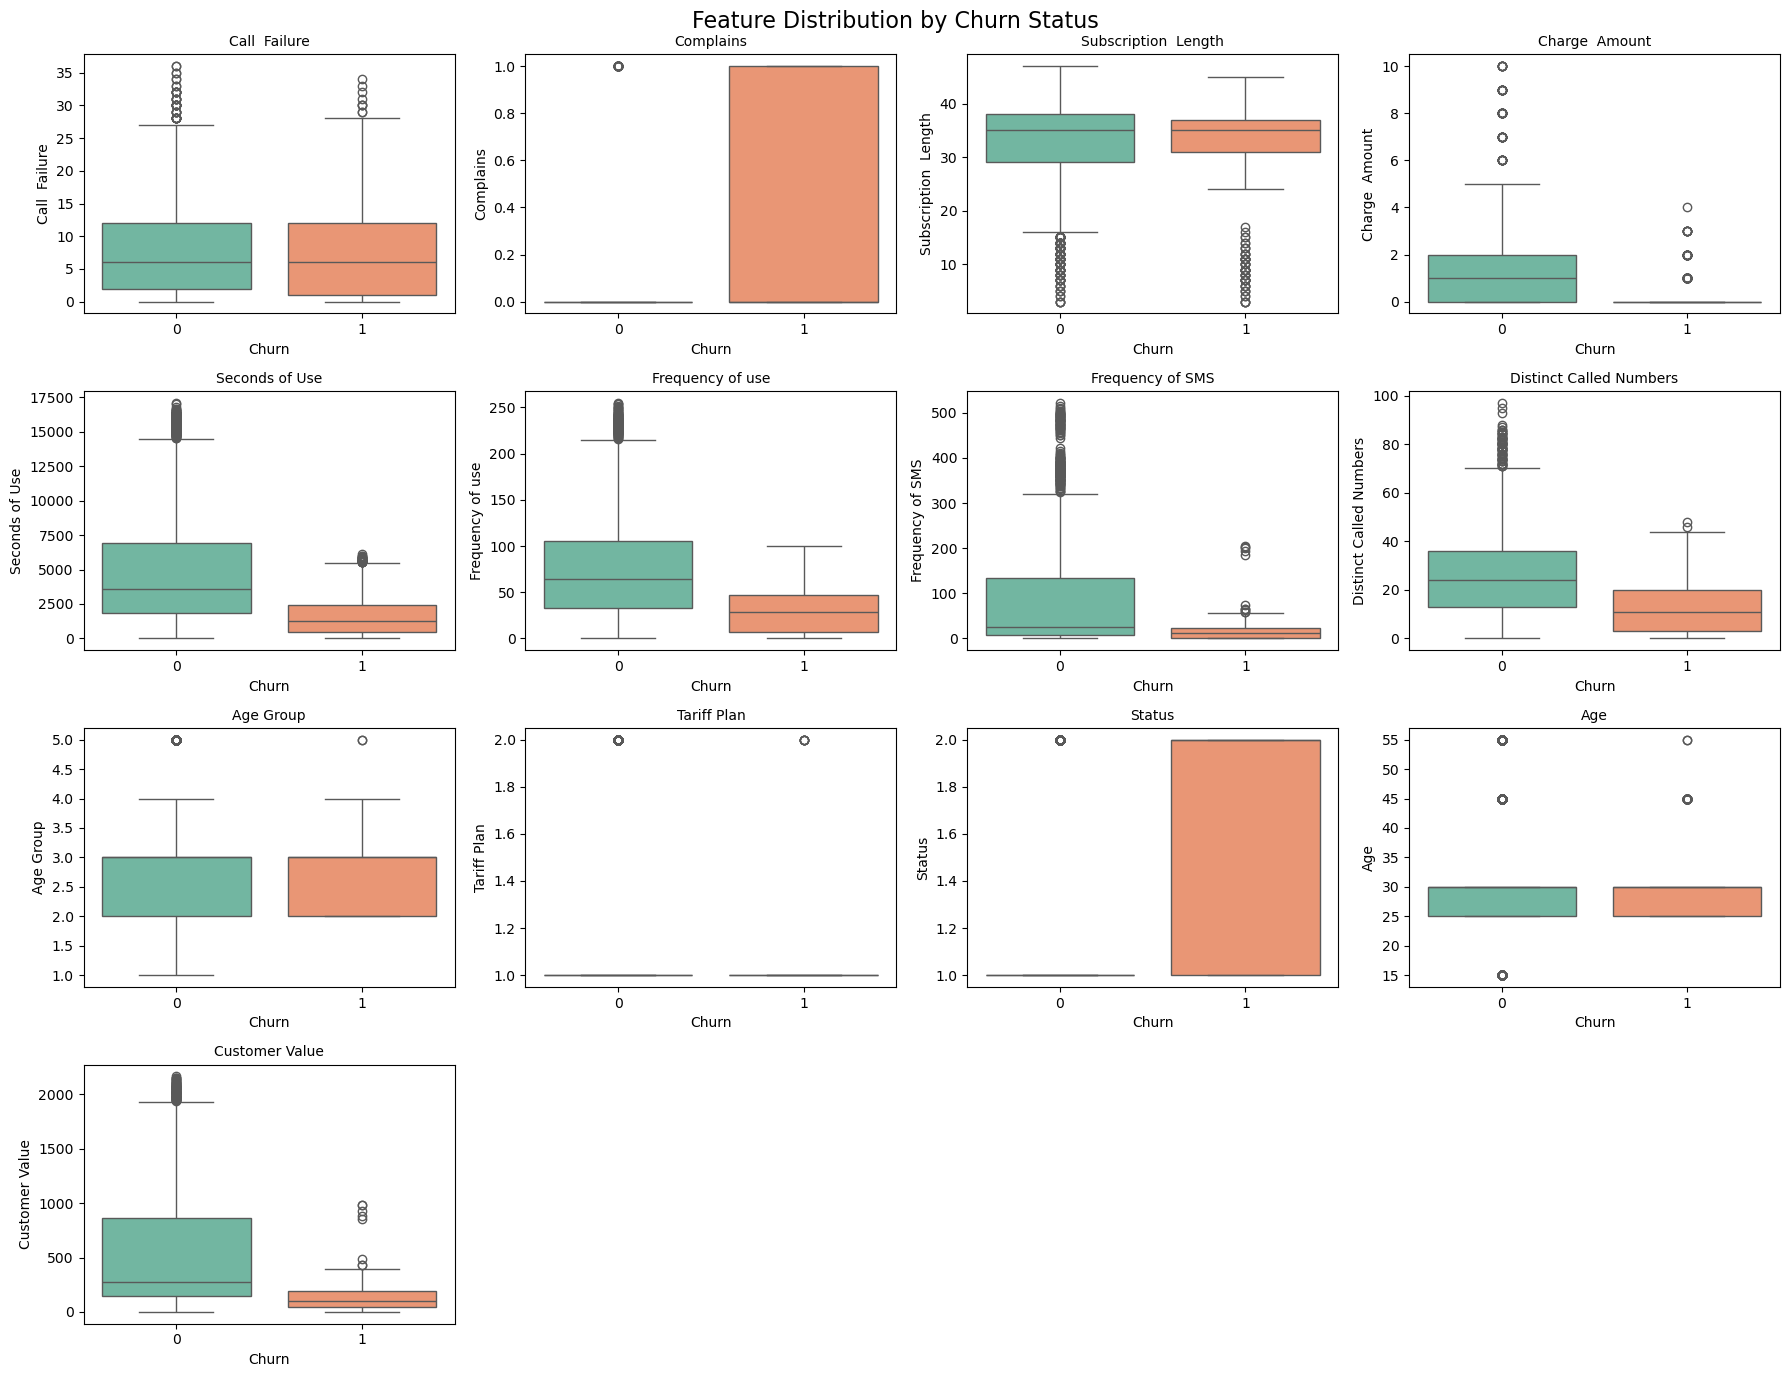

In [79]:
features = X.columns

fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(18, 14))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(
        data=churn,
        x="Churn",
        y=feature,
        hue="Churn",
        palette="Set2",
        legend=False,
        ax=axes[i]
    )
    axes[i].set_title(feature, fontsize=10)

# Remove empty subplot(s)
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Feature Distribution by Churn Status", fontsize=16)
plt.tight_layout()
plt.show()

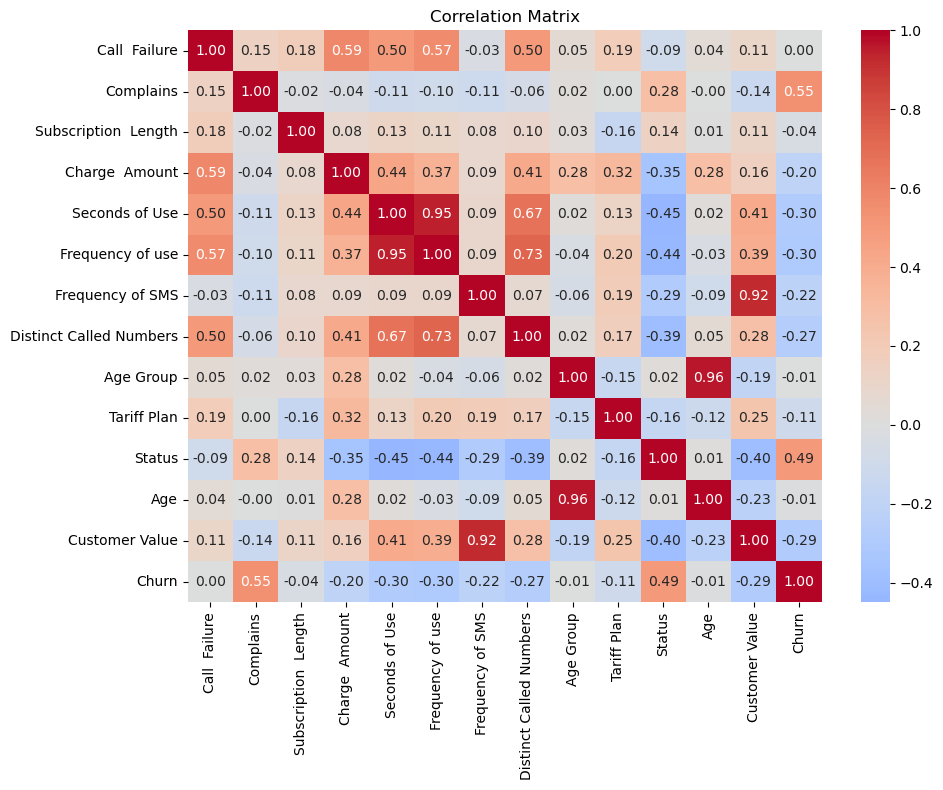

In [80]:
plt.figure(figsize=(10, 8))

corr = churn.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [85]:
pd.crosstab


<function pandas.core.reshape.pivot.crosstab(index, columns, values=None, rownames=None, colnames=None, aggfunc=None, margins: 'bool' = False, margins_name: 'Hashable' = 'All', dropna: 'bool' = True, normalize: "bool | Literal[0, 1, 'all', 'index', 'columns']" = False) -> 'DataFrame'>

In [82]:
Q1 = churn.quantile(0.25)
Q3 = churn.quantile(0.75)
IQR = Q3 - Q1

outlier_count = ((churn < (Q1 - 1.5 * IQR)) | (churn > (Q3 + 1.5 * IQR))).sum()

outlier_count.sort_values(ascending=False)

Status                     684
Age                        633
Churn                      446
Frequency of SMS           333
Complains                  230
Tariff Plan                229
Subscription  Length       208
Seconds of Use             189
Age Group                  154
Frequency of use           118
Customer Value             104
Distinct Called Numbers     82
Charge  Amount              62
Call  Failure               44
dtype: int64

## Outlier Analysis

Boxplots indicated several observations outside the IQR range across multiple features. However, for this project the outliers were **retained** for the following reasons:

* The dataset contains several **categorical/ordinal variables encoded as integers** (e.g., `Status`, `Tariff Plan`, `Age Group`, `Complains`), for which IQR-based outlier detection is not appropriate.
* **Decision Tree models are relatively robust to outliers**, since they split data based on feature thresholds rather than distance calculations.
* Extreme values in telecom usage features (e.g., `Seconds of Use`, `Frequency of SMS`, `Customer Value`) may represent **genuine heavy-usage customers** rather than erroneous records.

Therefore, no outlier removal was performed before training the Decision Tree classifier.


In [83]:
from sklearn.model_selection import train_test_split

X = churn.drop("Churn", axis=1)
y = churn["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (2280, 13)
X_test : (570, 13)
y_train: (2280,)
y_test : (570,)


In [86]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [87]:
y_pred = dt_model.predict(X_test)

In [88]:
from sklearn.metrics import accuracy_score

train_acc = accuracy_score(y_train, dt_model.predict(X_train))
test_acc = accuracy_score(y_test, y_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy :", test_acc)

Train Accuracy: 0.9956140350877193
Test Accuracy : 0.9315789473684211


## Baseline Decision Tree Evaluation

The initial Decision Tree model was trained using the default hyperparameters.

| Metric             |      Value |
| ------------------ | ---------: |
| **Train Accuracy** | **99.56%** |
| **Test Accuracy**  | **93.16%** |

### Interpretation

The model achieved **very high training accuracy**, but the test accuracy is noticeably lower, indicating that the tree is likely **overfitting** the training data.

Decision Trees can grow very deep when no constraints are applied, allowing them to memorize training examples rather than learn general patterns. In the next step, **GridSearchCV** will be used to tune parameters such as `max_depth`, `min_samples_split`, and `min_samples_leaf` in order to improve generalization performance.


In [89]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[466  15]
 [ 24  65]]


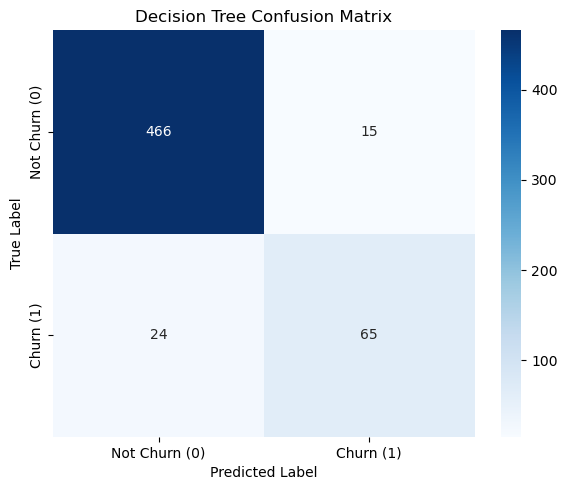

In [90]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Churn (0)", "Churn (1)"],
    yticklabels=["Not Churn (0)", "Churn (1)"]
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [91]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

print(classification_report(y_test, y_pred))

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")

              precision    recall  f1-score   support

           0       0.95      0.97      0.96       481
           1       0.81      0.73      0.77        89

    accuracy                           0.93       570
   macro avg       0.88      0.85      0.86       570
weighted avg       0.93      0.93      0.93       570

Precision: 0.812
Recall:    0.730
F1-score:  0.769


## Baseline Decision Tree Evaluation

### Business Objective

The goal of this project is to **predict customer churn** so that the telecom company can proactively retain customers who are likely to leave.

### Model Performance

| Metric                |      Value |
| --------------------- | ---------: |
| **Accuracy**          | **93.16%** |
| **Precision (Churn)** | **81.20%** |
| **Recall (Churn)**    | **73.00%** |
| **F1-score (Churn)**  | **76.90%** |

### Confusion Matrix

| Actual / Predicted | Not Churn |  Churn |
| ------------------ | --------: | -----: |
| **Not Churn**      |   **466** |     15 |
| **Churn**          |        24 | **65** |

### Business Interpretation

The model correctly identified **65 churning customers**, while **24 churning customers were missed**.

In a telecom business, **false negatives are more costly than false positives** because a missed churn customer may leave the company without receiving a retention offer.

### Engineering Decision

Although the model achieved **93.16% accuracy**, accuracy alone is not sufficient because the dataset is **imbalanced (84% non-churn, 16% churn)**.

For churn prediction, **Recall** is the more important metric since it measures the model's ability to detect customers who are actually at risk of leaving.

The baseline Decision Tree achieved:

* **High overall accuracy**
* **Good precision (0.812)**
* **Moderate recall (0.730)**

The relatively high training accuracy (**99.56%**) compared to test accuracy (**93.16%**) indicates **overfitting**.

### Next Action

The next step is to apply **GridSearchCV** to tune the Decision Tree hyperparameters (`max_depth`, `min_samples_split`, `min_samples_leaf`, and `criterion`) in order to:

1. Reduce overfitting,
2. Improve generalization,
3. Increase recall for churn customers,
4. Achieve a better balance between precision and recall.

This baseline model will serve as the reference point for evaluating all tuned Decision Tree models.


In [92]:
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [93]:
grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

In [94]:
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 10, 15, 20, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='recall')

In [95]:
print("Best Parameters:", grid.best_params_)

Best Parameters: {'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2}


## Hyperparameter Tuning Results

GridSearchCV was performed using **5-fold cross-validation** and **Recall** as the optimization metric.

### Best Parameters

| Parameter             | Selected Value |
| --------------------- | -------------: |
| **criterion**         |    **entropy** |
| **max_depth**         |         **20** |
| **min_samples_split** |          **2** |
| **min_samples_leaf**  |          **1** |

### Engineering Interpretation

The tuning process selected a **deep entropy-based Decision Tree**.

This indicates that a more complex tree was able to identify a greater proportion of churn customers during cross-validation.

However, these parameters also increase the risk of **overfitting**, since the tree is allowed to grow deeply and create very small leaf nodes.

The tuned model must therefore be evaluated on the **unseen test set** before making any deployment decision.

### Next Step

Evaluate the optimized model on the test dataset and compare it with the baseline model to determine whether recall improved and whether the increase in model complexity is justified.


In [96]:
print("Best CV Recall:", grid.best_score_)

Best CV Recall: 0.8035993740219093


In [97]:
best_dt = grid.best_estimator_

y_pred_tuned = best_dt.predict(X_test)

In [98]:
train_acc_tuned = accuracy_score(y_train, best_dt.predict(X_train))
test_acc_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)

print("Train Accuracy:", train_acc_tuned)
print("Test Accuracy :", test_acc_tuned)
print("Precision     :", precision_tuned)
print("Recall        :", recall_tuned)
print("F1-score      :", f1_tuned)

Train Accuracy: 0.9956140350877193
Test Accuracy : 0.9350877192982456
Precision     : 0.7653061224489796
Recall        : 0.8426966292134831
F1-score      : 0.8021390374331551


## Tuned Decision Tree Evaluation

The optimized Decision Tree model obtained from **GridSearchCV** was evaluated on the unseen test dataset.

### Performance Comparison

| Metric             | Baseline |      Tuned |
| ------------------ | -------: | ---------: |
| **Train Accuracy** |   99.56% |     99.56% |
| **Test Accuracy**  |   93.16% | **93.51%** |
| **Precision**      |   81.20% |     76.53% |
| **Recall**         |   73.00% | **84.27%** |
| **F1-score**       |   76.90% | **80.21%** |

### Engineering Interpretation

The tuned model achieved a **substantial improvement in Recall**, increasing from **73.0% to 84.3%**.

This means the model is able to identify **a significantly larger proportion of customers who are likely to churn**.

Although Precision decreased slightly, the increase in Recall is more valuable for a **customer retention problem**, where failing to detect a churn customer is typically more expensive than contacting a customer who would have remained.

### Deployment Decision

For a telecom churn prediction system, the **tuned Decision Tree model is selected** because it provides:

* Higher Recall,
* Higher F1-score,
* Slightly higher Test Accuracy,
* Better alignment with the business objective of **customer retention**.

The tuned model will therefore be used as the final Decision Tree classifier for predicting customer churn.


In [99]:
feature_importance = pd.Series(
    best_dt.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance

Status                     0.240808
Complains                  0.161498
Seconds of Use             0.130949
Subscription  Length       0.105968
Call  Failure              0.070871
Customer Value             0.070036
Frequency of use           0.065117
Frequency of SMS           0.058739
Distinct Called Numbers    0.049296
Age Group                  0.027556
Age                        0.019161
Charge  Amount             0.000000
Tariff Plan                0.000000
dtype: float64

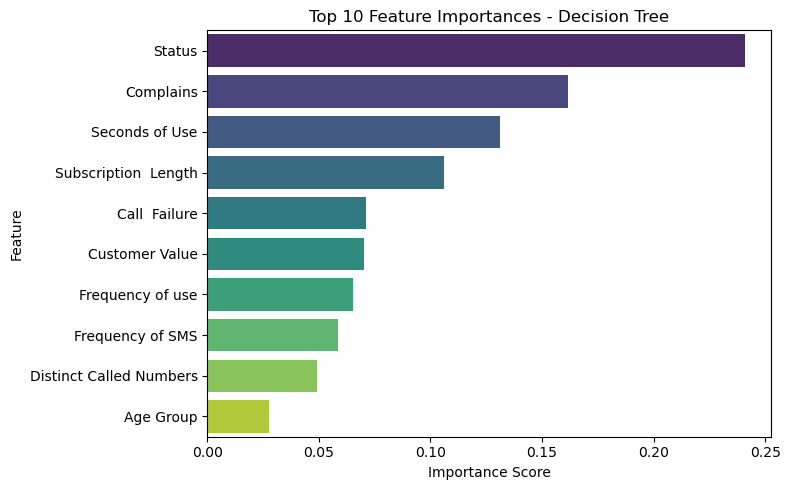

In [100]:
top_features = feature_importance.head(10)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=top_features.values,
    y=top_features.index,
    hue=top_features.index,
    palette="viridis",
    legend=False
)

plt.title("Top 10 Feature Importances - Decision Tree")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Feature Importance Analysis

Decision Trees provide a built-in measure of **feature importance**, indicating how much each feature contributes to reducing impurity across the tree.

The top 10 most influential features were visualized using a **Seaborn horizontal bar chart**.

### Engineering Interpretation

Features with higher importance scores have a greater influence on the model's decision-making process.

These features represent the primary drivers of customer churn and can be used by the telecom company to:

* prioritize customer retention campaigns,
* improve customer support processes,
* identify high-risk customers,
* and guide future feature engineering efforts.

Feature importance also improves **model interpretability**, which is a major advantage of Decision Tree models compared with many black-box algorithms.


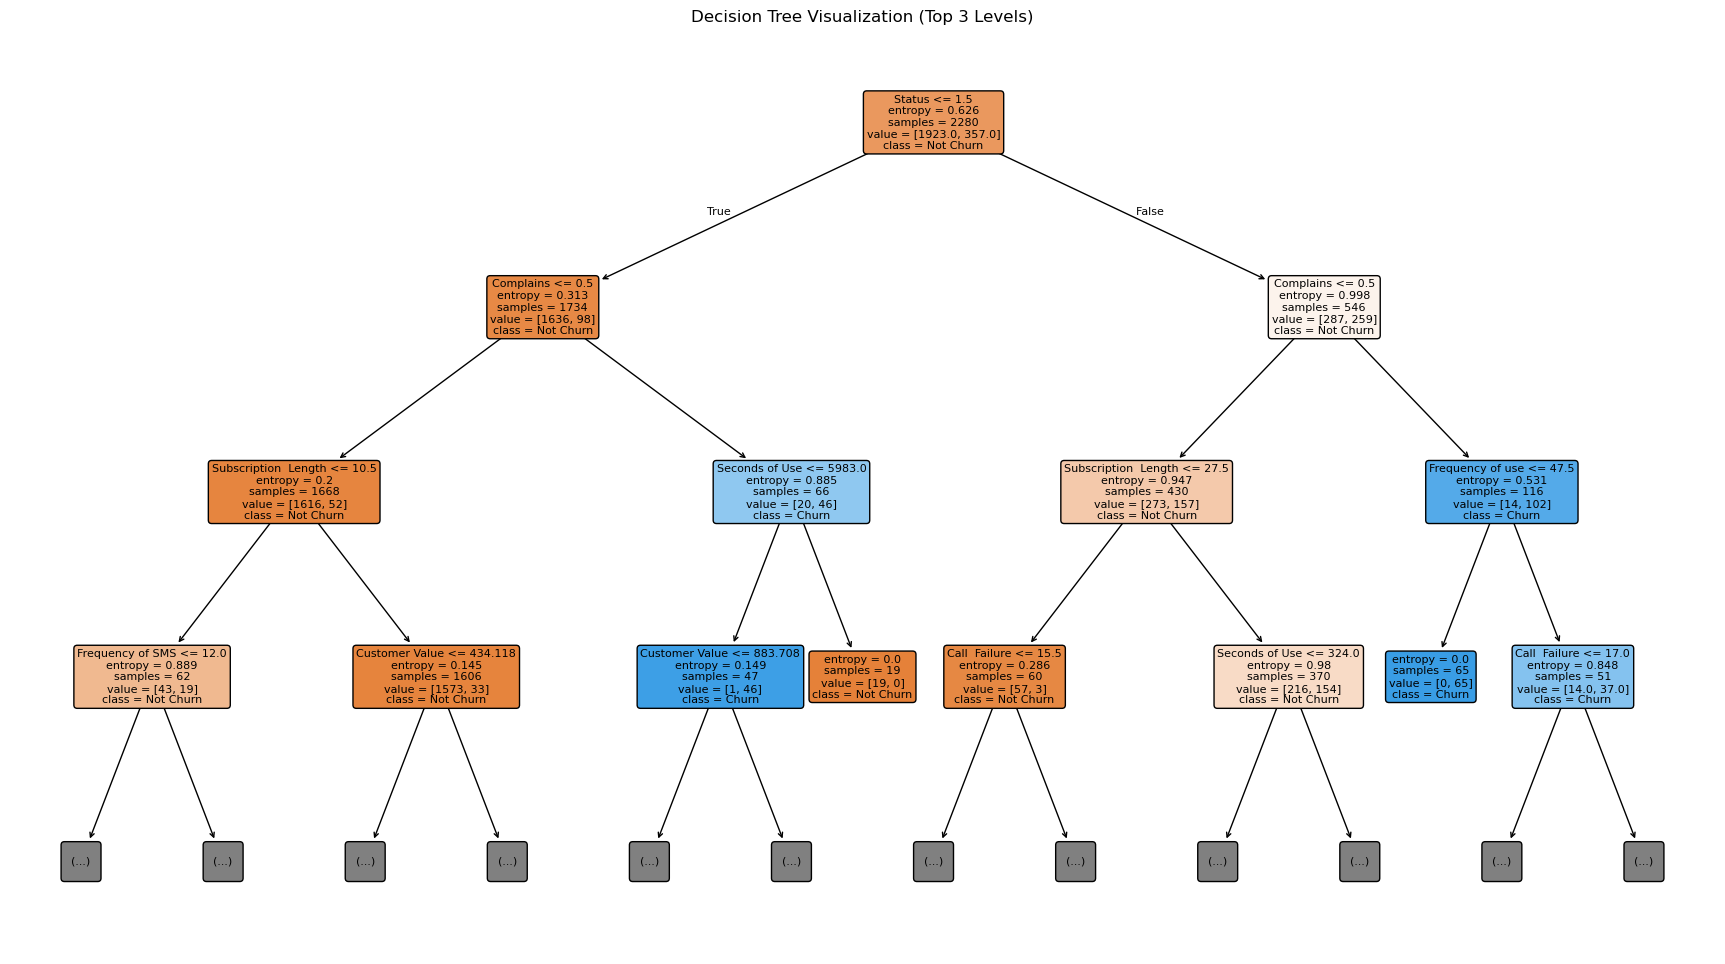

In [101]:
plt.figure(figsize=(22, 12))

plot_tree(
    best_dt,
    feature_names=X.columns,
    class_names=["Not Churn", "Churn"],
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3
)

plt.title("Decision Tree Visualization (Top 3 Levels)")
plt.show()

## Decision Tree Visualization

The tuned Decision Tree was visualized using `plot_tree()`.

Because the optimized tree has a **maximum depth of 20**, only the **top three levels** were displayed to maintain readability.

### Interpretation

Each node represents:

* a **feature-based decision rule**,
* the **entropy** (node impurity),
* the **number of training samples**,
* the **class distribution**,
* and the **predicted class**.

The visualization provides a transparent explanation of how the model makes predictions, making Decision Trees highly **interpretable** compared with many black-box machine learning models.

This interpretability is particularly valuable in business applications such as customer churn prediction, where stakeholders often require understandable decision rules before deploying a model.


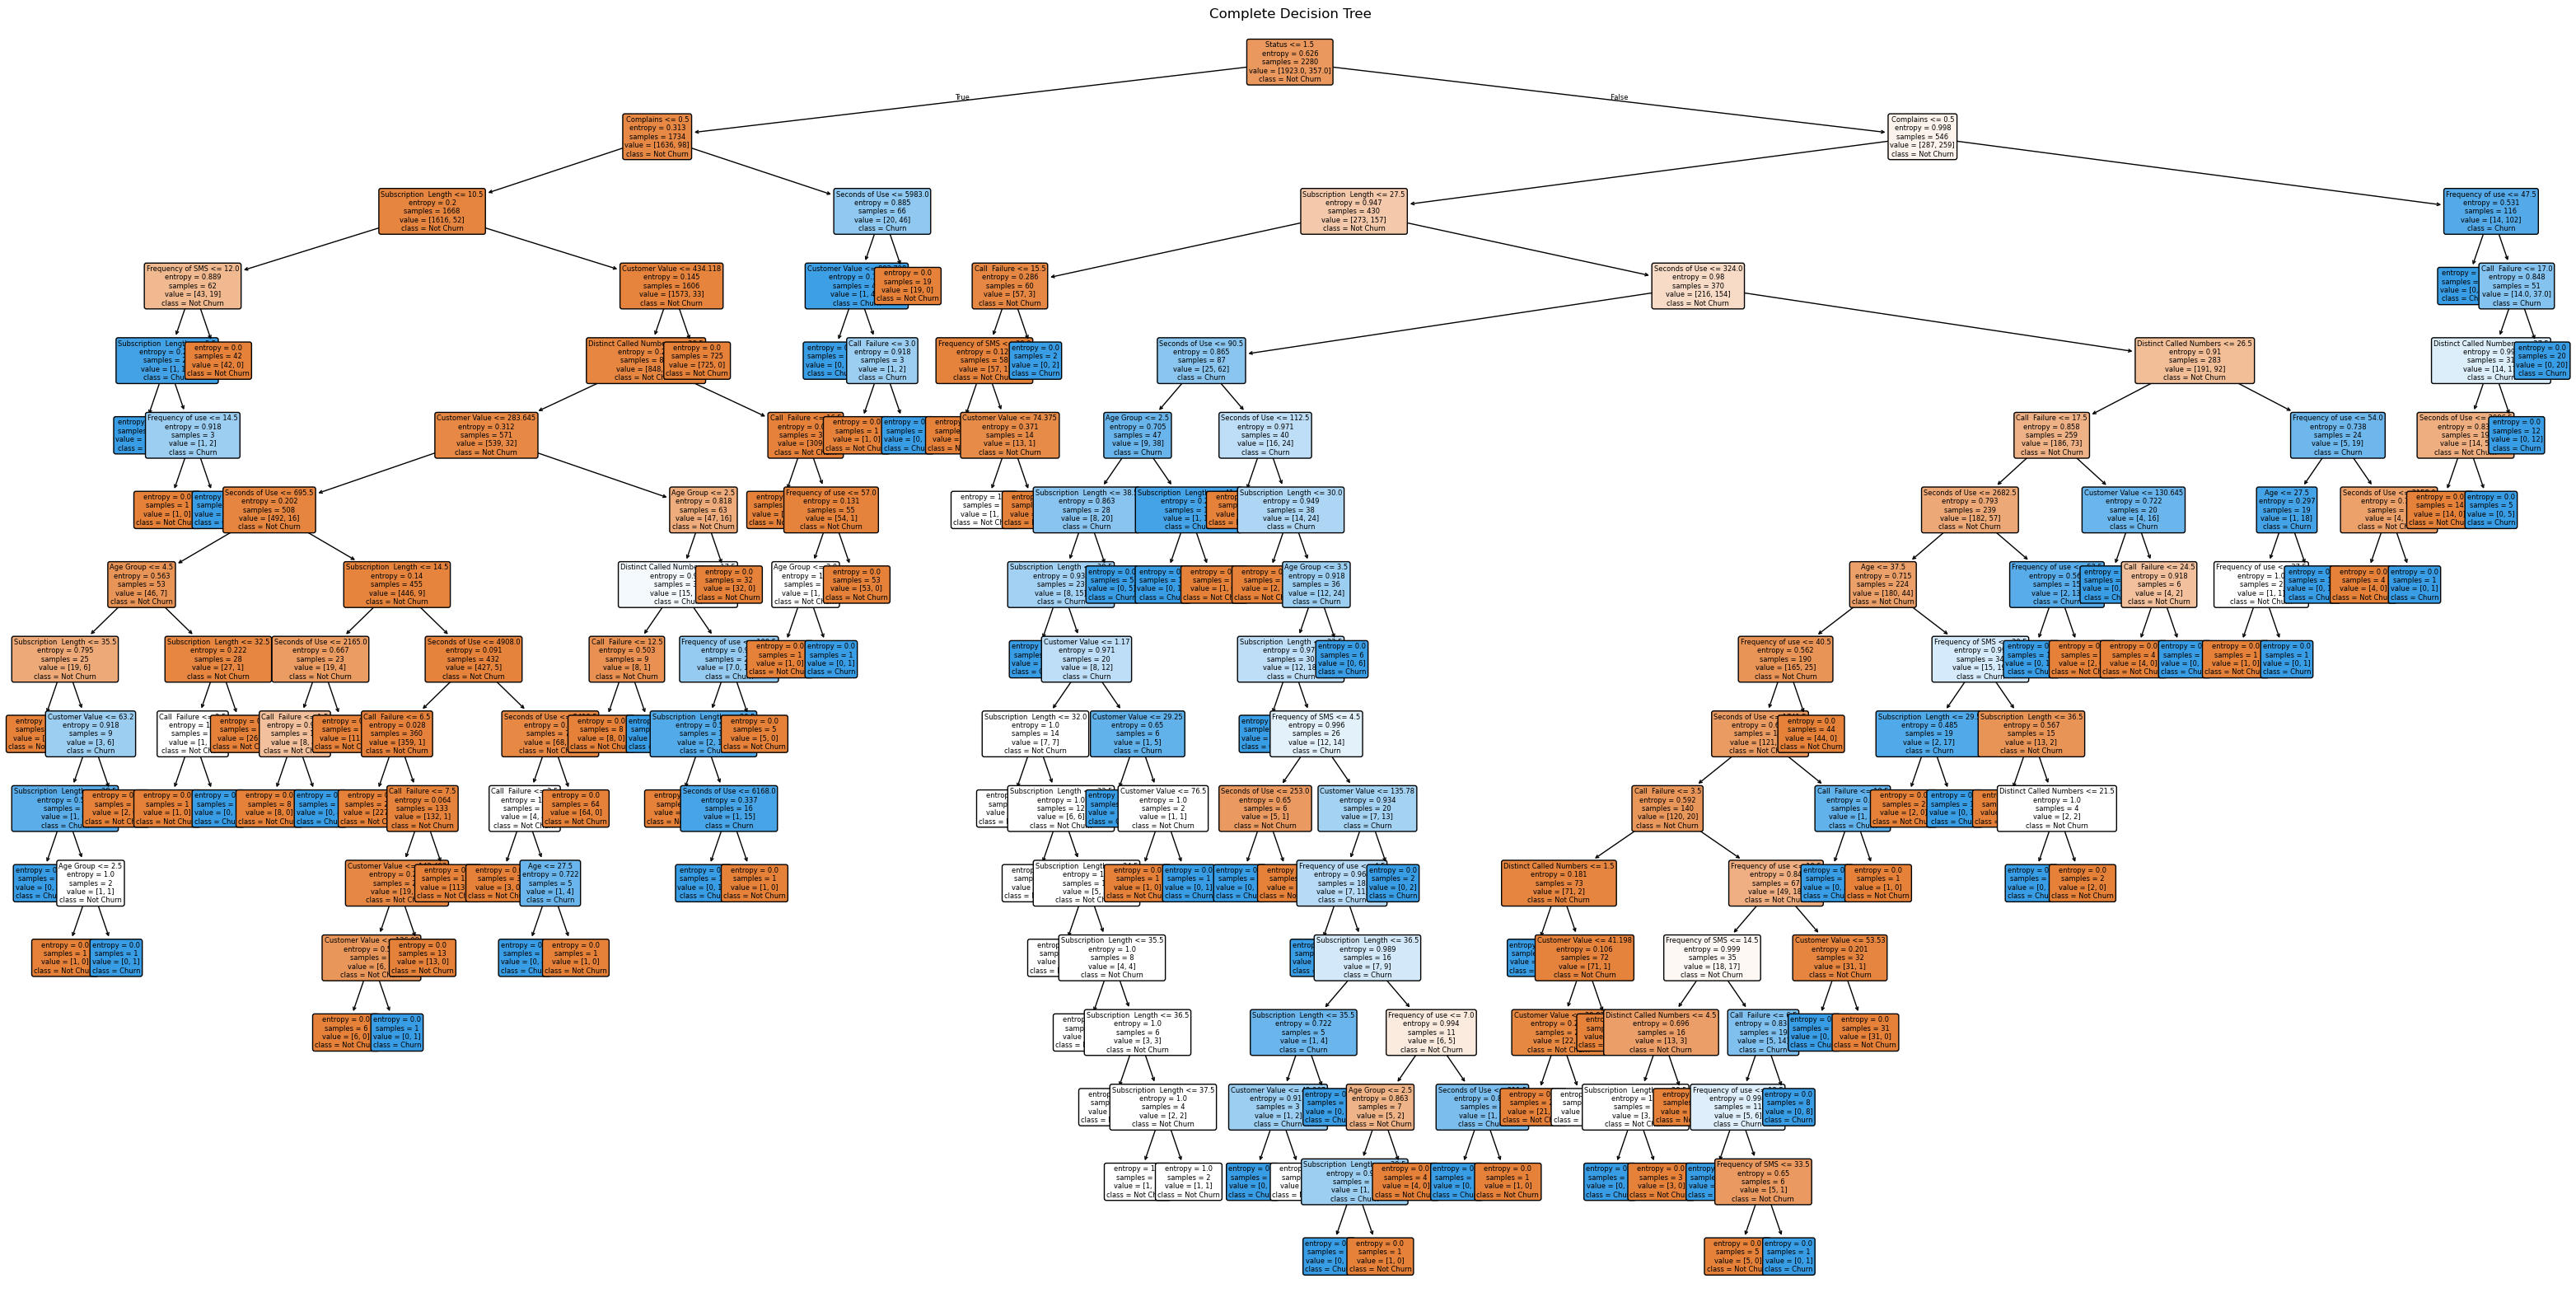

In [102]:
plt.figure(figsize=(40, 20))

plot_tree(
    best_dt,
    feature_names=X.columns,
    class_names=["Not Churn", "Churn"],
    filled=True,
    rounded=True,
    fontsize=6
)

plt.title("Complete Decision Tree")
plt.show()

In [105]:
pip install graphviz

Note: you may need to restart the kernel to use updated packages.
